# 06 — Comprehensive Performance & Error Metrics Visualizations

This notebook loads the evaluation metrics (`predictions` and `labels`) for all four architectures across the entire experimental sweep. 
It utilizes an optimized single-pass engine to extract error metrics, caches the result, and generates:
1. **Precision vs. Recall Distribution Curves** (Model trained on 25% corruption).
2. **False Positive Rate (FPR) vs. False Negative Rate (FNR)** trade-offs (Model trained on 0% corruption).
3. **Per-Class Error Rate Heatmaps** (Model trained on 0% corruption).


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

print("check1")
current_dir = Path().resolve()
if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

print("check2")


RESULTS_DIR = PROJECT_ROOT / "outputs" / "model_runs"
PLOTS_DIR = RESULTS_DIR / "detailed_metric_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("check3")

# Dataset Attributes
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
TARGET_MODELS = ["resnet18", "resnet50", "densenet121", "toy_cnn"]

def get_results_path(model_name):
    return RESULTS_DIR / f"{model_name}_full_results.json"

print("--- System Verification ---")
print("Project Root identified as:", PROJECT_ROOT)
print("Looking for JSON results in:", RESULTS_DIR)
print("Output plots will save to:  ", PLOTS_DIR)

# Sanity check to verify files are visible before continuing
print("\nChecking file visibility:")
for model in TARGET_MODELS:
    path = get_results_path(model)
    print(f"  {model}_full_results.json -> {'FOUND' if path.exists() else 'NOT FOUND'}")

check1
check2
check3
--- System Verification ---
Project Root identified as: C:\Users\17187\badnets-medical-imaging
Looking for JSON results in: C:\Users\17187\badnets-medical-imaging\outputs\model_runs
Output plots will save to:   C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots

Checking file visibility:
  resnet18_full_results.json -> FOUND
  resnet50_full_results.json -> FOUND
  densenet121_full_results.json -> FOUND
  toy_cnn_full_results.json -> FOUND


In [2]:
def extract_error_rates(cache_file="computed_error_rates.csv"):
    """Parses raw prediction arrays once, tracks progress, and caches results to a CSV file."""
    cache_path = RESULTS_DIR / cache_file
    if cache_path.exists():
        print(f"Loading cached metrics from {cache_path}... (Instant)")
        return pd.read_csv(cache_path)
        
    print("No cache found. Running fast single-pass extraction across all models...")
    rows = []
    
    total_models = len(TARGET_MODELS)
    
    for m_idx, model_name in enumerate(TARGET_MODELS, 1):
        path = get_results_path(model_name)
        if not path.exists():
            print(f"  [{m_idx}/{total_models}] Skipping {model_name} — No JSON results file found.")
            continue
            
        print(f"\n>>> Processing model [{m_idx}/{total_models}]: {model_name}...")
        
        with open(path) as f:
            raw_data = json.load(f)
            
        keys = list(raw_data.items())
        total_keys = len(keys)
        
        for k_idx, (key, result) in enumerate(keys, 1):
            corruption = result["corruption_type"]
            train_frac = result["train_fraction"]
            
            if k_idx == 1 or k_idx % 5 == 0 or k_idx == total_keys:
                print(f"    -> Configuration {k_idx}/{total_keys}: processing {corruption} (train={train_frac:.0%})")
            
            for test_frac_str, test_res in result["test_results"].items():
                test_frac = float(test_frac_str)
                preds = test_res["predictions"]
                labels = test_res["labels"]
                
                cm = confusion_matrix(labels, preds, labels=list(range(len(CLASS_NAMES))))
                
                for idx, class_name in enumerate(CLASS_NAMES):
                    tp = cm[idx, idx]
                    fp = np.sum(cm[:, idx]) - tp
                    fn = np.sum(cm[idx, :]) - tp
                    tn = np.sum(cm) - tp - fp - fn
                    
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
                    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
                    
                    rows.append({
                        "model": model_name,
                        "corruption_type": corruption,
                        "train_fraction": train_frac,
                        "test_fraction": test_frac,
                        "class_name": class_name,
                        "precision": precision,
                        "recall": recall,
                        "fpr": fpr,
                        "fnr": fnr
                    })
                    
    df_out = pd.DataFrame(rows)
    df_out.to_csv(cache_path, index=False)
    print(f"\nProcessing complete! Cached calculations to: {cache_path}")
    return df_out

metrics_df = extract_error_rates()
metrics_df.head()

No cache found. Running fast single-pass extraction across all models...

>>> Processing model [1/4]: resnet18...
    -> Configuration 1/22: processing none (train=0%)
    -> Configuration 5/22: processing beam_hardening (train=0%)
    -> Configuration 10/22: processing gaussian_noise (train=25%)
    -> Configuration 15/22: processing motion_ghosting (train=10%)
    -> Configuration 20/22: processing combination (train=0%)
    -> Configuration 22/22: processing combination (train=25%)

>>> Processing model [2/4]: resnet50...
    -> Configuration 1/22: processing none (train=0%)
    -> Configuration 5/22: processing beam_hardening (train=0%)
    -> Configuration 10/22: processing gaussian_noise (train=25%)
    -> Configuration 15/22: processing motion_ghosting (train=10%)
    -> Configuration 20/22: processing combination (train=0%)
    -> Configuration 22/22: processing combination (train=25%)

>>> Processing model [3/4]: densenet121...
    -> Configuration 1/22: processing none (train

,model,corruption_type,train_fraction,test_fraction,class_name,precision,recall,fpr,fnr
0,resnet18,none,0.0,0.0,glioma,0.994012,0.8300,0.001667,0.1700
1,resnet18,none,0.0,0.0,meningioma,0.898851,0.9775,0.036667,0.0225
2,resnet18,none,0.0,0.0,notumor,0.938824,0.9975,0.021667,0.0025
3,resnet18,none,0.0,0.0,pituitary,0.985222,1.0000,0.005000,0.0000
4,resnet18,jpeg_compression,0.0,0.0,glioma,0.993827,0.8050,0.001667,0.1950


## Visual 1: Precision-Recall Curves Across All Models

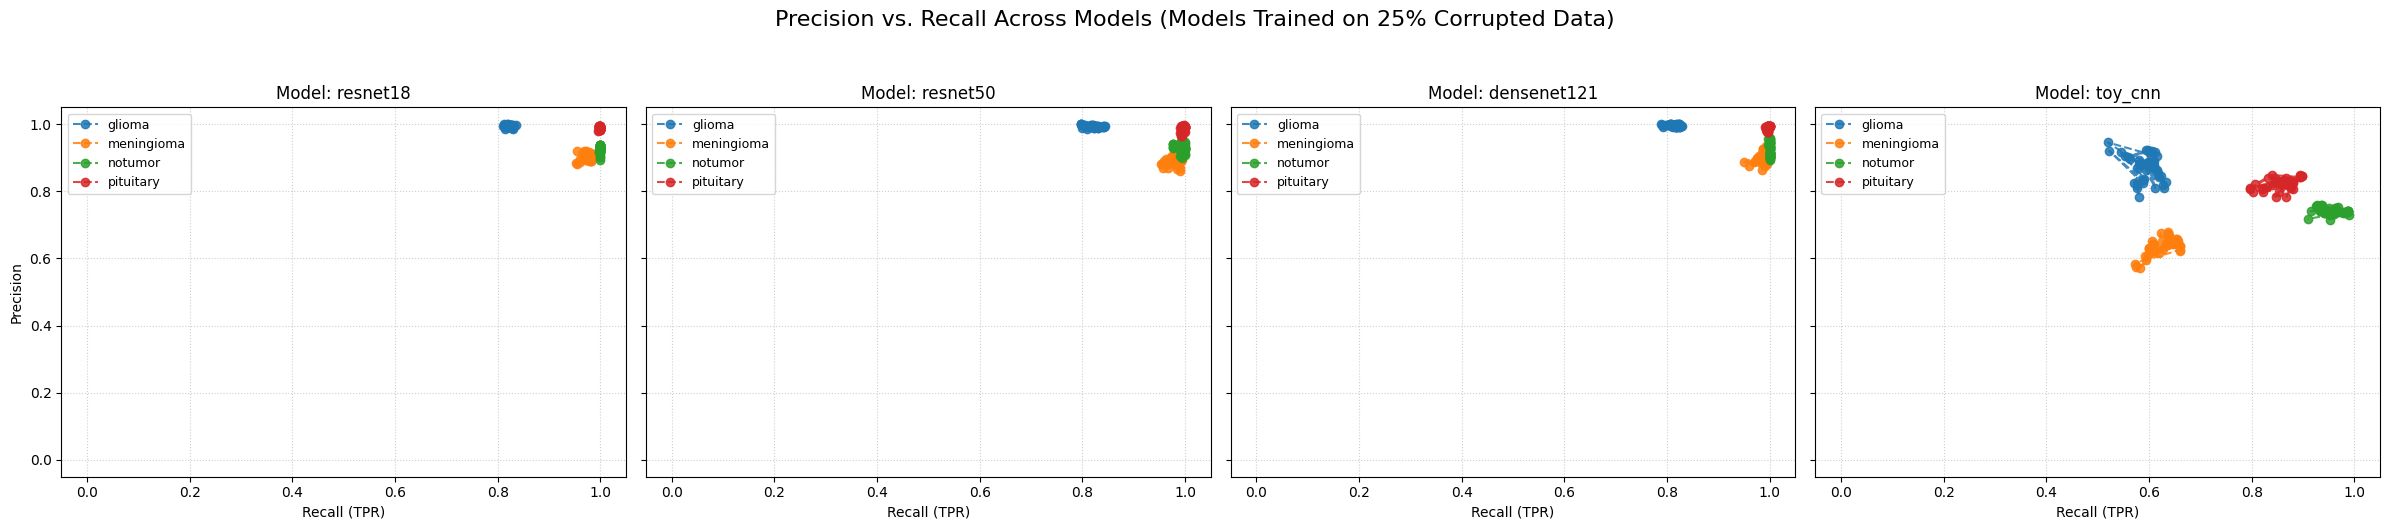

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\precision_recall_comparison.png


In [3]:
def plot_precision_recall_curves(df):
    """Plots Precision vs Recall curves across test corruption levels."""
    fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
    fig.suptitle("Precision vs. Recall Across Models (Models Trained on 25% Corrupted Data)", fontsize=16, y=1.05)
    
    # Fast filtering on the pre-computed dataframe
    subset = df[df["train_fraction"] == 0.25]
    
    for idx, model in enumerate(TARGET_MODELS):
        ax = axes[idx]
        model_df = subset[subset["model"] == model]
        
        for class_name in CLASS_NAMES:
            class_df = model_df[model_df["class_name"] == class_name].sort_values("test_fraction")
            ax.plot(class_df["recall"], class_df["precision"], 'o--', label=class_name, alpha=0.85)
            
        ax.set_title(f"Model: {model}", fontsize=12)
        ax.set_xlabel("Recall (TPR)")
        if idx == 0:
            ax.set_ylabel("Precision")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(fontsize=9)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(-0.05, 1.05)
        
    plt.tight_layout()
    save_path = PLOTS_DIR / "precision_recall_comparison.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

plot_precision_recall_curves(metrics_df)

## Visual 2: False Positive vs. False Negative Operational Trade-off

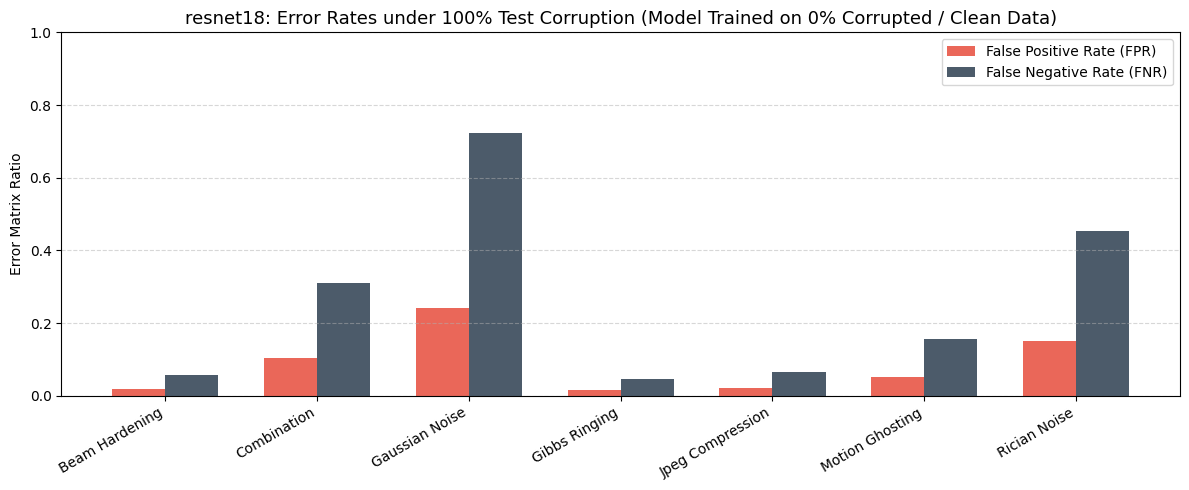

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\resnet18_fpr_fnr_error_bars.png


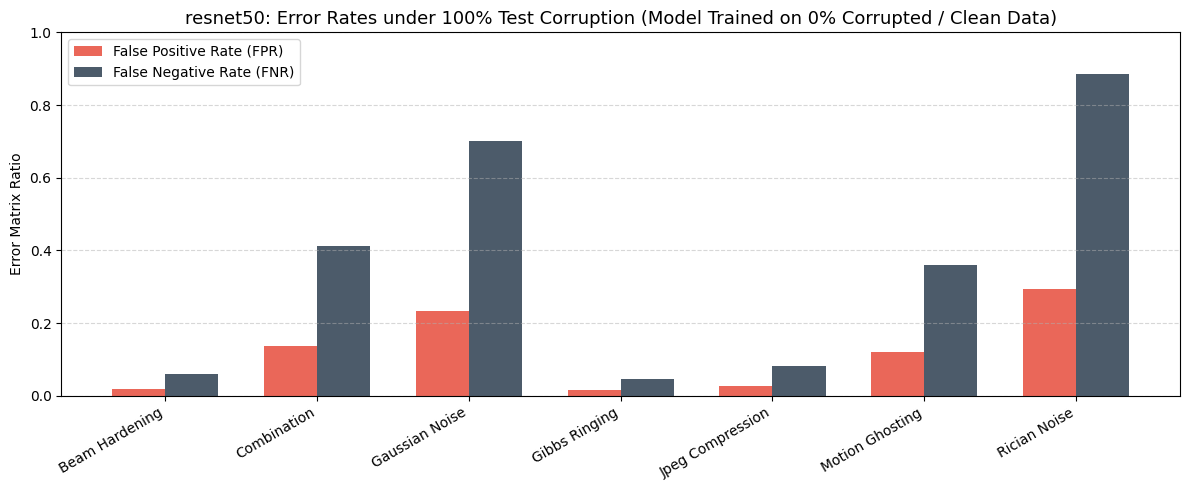

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\resnet50_fpr_fnr_error_bars.png


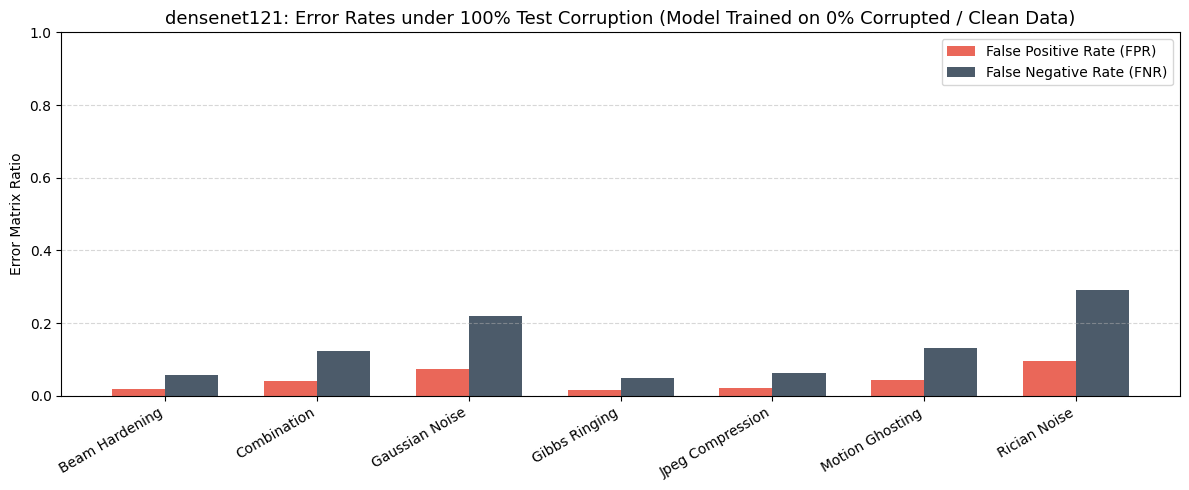

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\densenet121_fpr_fnr_error_bars.png


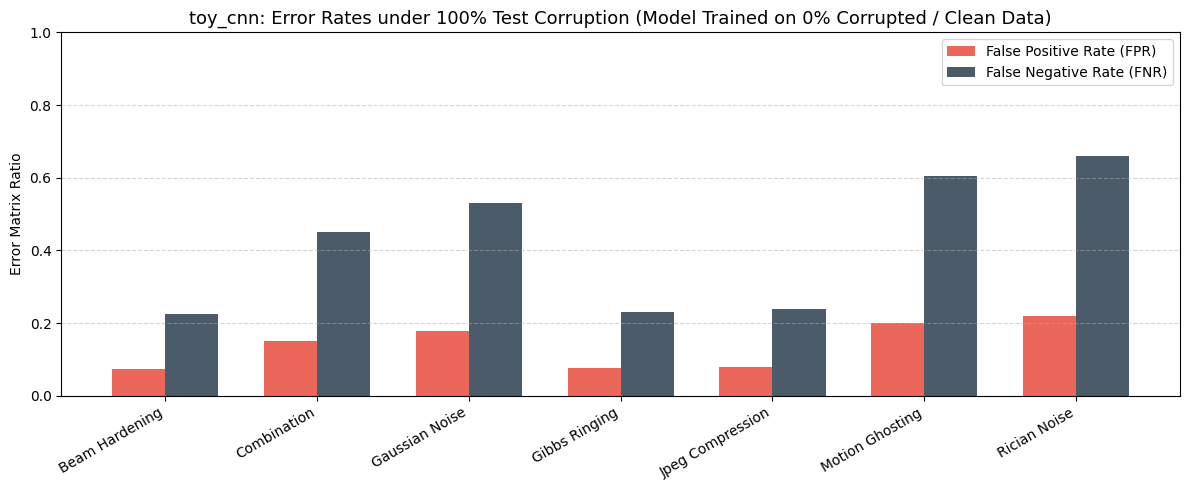

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\toy_cnn_fpr_fnr_error_bars.png


In [4]:
def plot_error_rate_tradeoff(df):
    """Generates group bar plots highlighting False Positive vs False Negative Rates."""
    severe_df = df[(df["test_fraction"] == 1.0) & (df["train_fraction"] == 0.0)]
    
    if severe_df.empty:
        print("No matches found for severe evaluation parameters.")
        return
        
    grouped = severe_df.groupby(["model", "corruption_type"])[["fpr", "fnr"]].mean().reset_index()
    
    for model in TARGET_MODELS:
        model_data = grouped[grouped["model"] == model]
        if model_data.empty:
            continue
            
        x = np.arange(len(model_data["corruption_type"]))
        width = 0.35
        
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(x - width/2, model_data["fpr"], width, label='False Positive Rate (FPR)', color='#e74c3c', alpha=0.85)
        ax.bar(x + width/2, model_data["fnr"], width, label='False Negative Rate (FNR)', color='#2c3e50', alpha=0.85)
        
        ax.set_title(f"{model}: Error Rates under 100% Test Corruption (Model Trained on 0% Corrupted / Clean Data)", fontsize=13)
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace("_", " ").title() for c in model_data["corruption_type"]], rotation=30, ha="right")
        ax.set_ylabel("Error Matrix Ratio")
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.legend()
        
        plt.tight_layout()
        save_path = PLOTS_DIR / f"{model}_fpr_fnr_error_bars.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {save_path}")

plot_error_rate_tradeoff(metrics_df)

## Visual 3: Per-Class Metric Failure Matrix Heatmaps

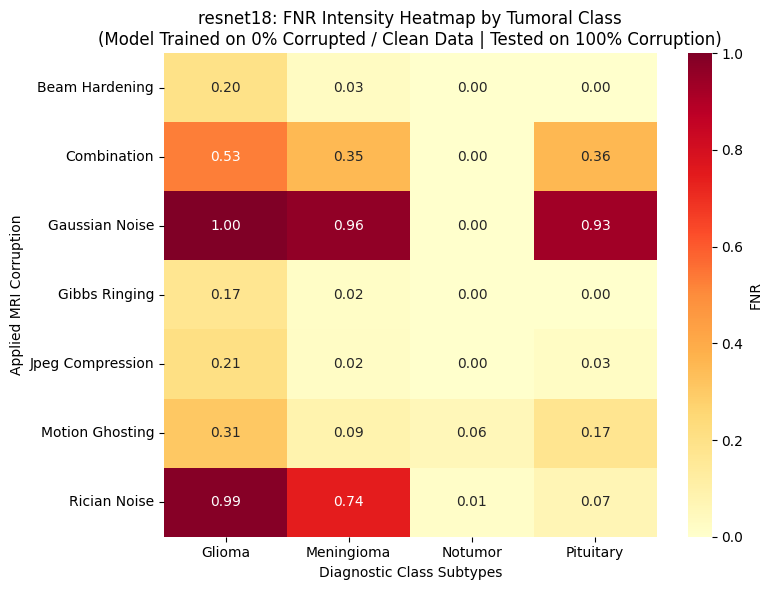

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\resnet18_fnr_matrix_heatmap.png


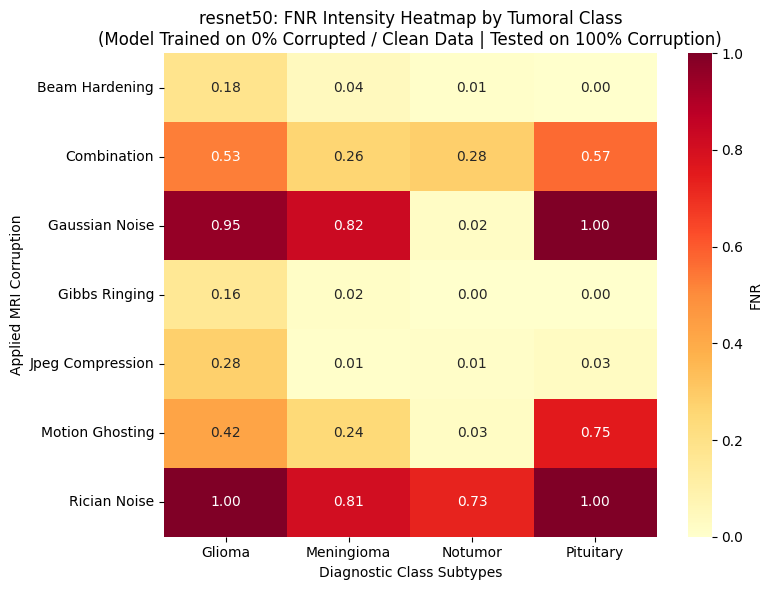

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\resnet50_fnr_matrix_heatmap.png


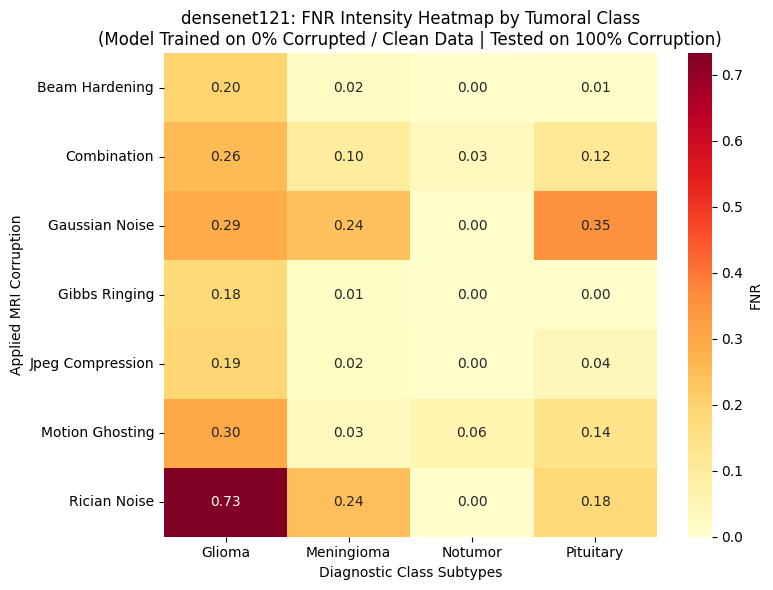

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\densenet121_fnr_matrix_heatmap.png


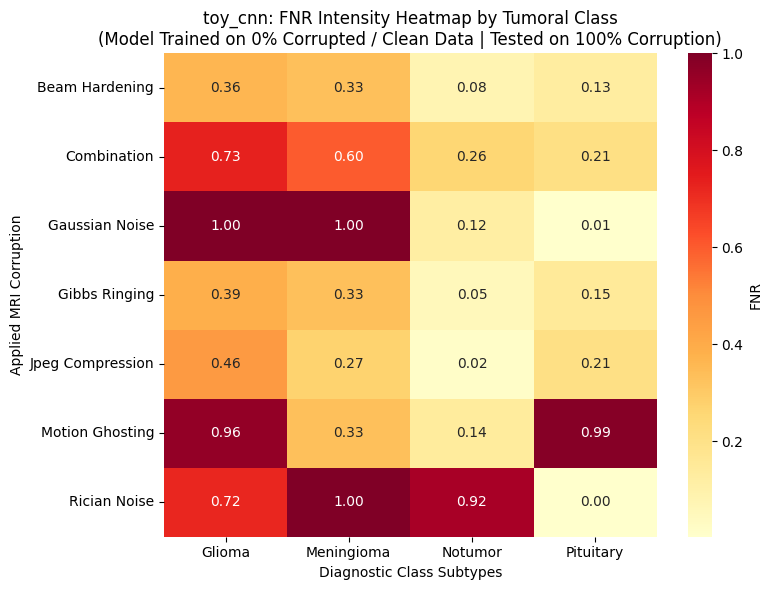

Saved: C:\Users\17187\badnets-medical-imaging\outputs\model_runs\detailed_metric_plots\toy_cnn_fnr_matrix_heatmap.png


In [5]:
def plot_metric_heatmaps(df, target_metric="fnr"):
    """Generates detailed heatmaps reflecting error metrics across all corruptions and classes."""
    matrix_df = df[(df["train_fraction"] == 0.0) & (df["test_fraction"] == 1.0)]
    
    for model in TARGET_MODELS:
        model_df = matrix_df[matrix_df["model"] == model]
        if model_df.empty:
            continue
            
        pivot = model_df.pivot_table(
            index="corruption_type",
            columns="class_name",
            values=target_metric
        )
        
        pivot.index = [idx.replace("_", " ").title() for idx in pivot.index]
        pivot.columns = [col.title() for col in pivot.columns]
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': target_metric.upper()})
        plt.title(f"{model}: {target_metric.upper()} Intensity Heatmap by Tumoral Class\n(Model Trained on 0% Corrupted / Clean Data | Tested on 100% Corruption)")
        plt.xlabel("Diagnostic Class Subtypes")
        plt.ylabel("Applied MRI Corruption")
        
        plt.tight_layout()
        save_path = PLOTS_DIR / f"{model}_{target_metric}_matrix_heatmap.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {save_path}")

plot_metric_heatmaps(metrics_df, target_metric="fnr")